✅ PM4Py Calcoli funzionano!
Relazioni trovate: {('Check', 'End'): 1, ('Start', 'Check'): 1, ('Start', 'End'): 1}


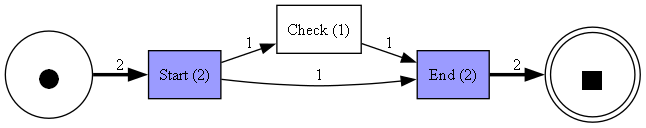

✅ Visualizzazione Graphviz funzionante!


In [1]:
import pm4py
import pandas as pd

# 1. Creiamo un "Event Log" finto (simuliamo un processo semplice)
# A -> B -> C (Caso 1)
# A -> C      (Caso 2)
data = {
    "case_id": ["1", "1", "1", "2", "2"],
    "activity": ["Start", "Check", "End", "Start", "End"],
    "timestamp": [
        "2023-01-01 10:00:00", "2023-01-01 10:05:00", "2023-01-01 10:10:00",
        "2023-01-01 11:00:00", "2023-01-01 11:10:00"
    ]
}
df = pd.DataFrame(data)

# 2. Formattiamo per PM4Py
df = pm4py.format_dataframe(df, case_id='case_id', activity_key='activity', timestamp_key='timestamp')

# 3. Scopriamo il grafo (Directly-Follows Graph)
# Questo calcola quante volte si passa da A a B
dfg, start_activities, end_activities = pm4py.discover_dfg(df)

print("✅ PM4Py Calcoli funzionano!")
print(f"Relazioni trovate: {dfg}")

# 4. (Opzionale) Proviamo a visualizzarlo
# Se questo fallisce, ti manca Graphviz su Windows
try:
    pm4py.view_dfg(dfg, start_activities, end_activities)
    print("✅ Visualizzazione Graphviz funzionante!")
except Exception as e:
    print("⚠️ I calcoli vanno, ma la visualizzazione no. Ti manca Graphviz installato su Windows?")
    print(e)

In [2]:
import polars as pl
import duckdb

# 1. Creiamo un DataFrame Polars veloce
df_polars = pl.DataFrame({
    "id": [1, 2, 3, 4],
    "valore": [10, 20, 30, 40],
    "categoria": ["A", "A", "B", "B"]
})

# 2. Usiamo DuckDB per interrogarlo come se fosse una tabella SQL reale
# DuckDB è così potente che vede le variabili Python in memoria!
query = "SELECT categoria, SUM(valore) as totale FROM df_polars GROUP BY categoria"
result = duckdb.query(query).pl() # .pl() converte il risultato di nuovo in Polars

print("✅ Polars e DuckDB integrati perfettamente!")
print(result)

✅ Polars e DuckDB integrati perfettamente!
shape: (2, 2)
┌───────────┬───────────────┐
│ categoria ┆ totale        │
│ ---       ┆ ---           │
│ str       ┆ decimal[38,0] │
╞═══════════╪═══════════════╡
│ B         ┆ 70            │
│ A         ┆ 30            │
└───────────┴───────────────┘
